scPred-Py initialized. Remember this is a starting point!
--- Step 1: Loading and Annotating Data ---
Initial raw AnnData object shape: (2700, 32738)
Initial raw AnnData .obs keys: []
Initial raw AnnData .var keys: ['gene_ids']

Generating temporary cell type labels via Louvain clustering...


/usr/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/eva/Class-Project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Full dataset (raw counts + Louvain labels) shape: (2700, 32738)
Full dataset .obs keys after labeling: ['cell_type']
Cell type distribution (all data):
 cell_type
0    815
1    467
2    459
3    371
4    345
5    184
6     45
7     14
Name: count, dtype: int64

--- Step 2: Splitting Data (Stratified) ---
Reference data (raw + labels) shape: (1890, 32738)
Query data (raw + labels) shape: (810, 32738)

Reference cell type distribution:
 cell_type
0    570
1    327
2    321
3    260
4    241
5    129
6     32
7     10
Name: count, dtype: int64

Query cell type distribution:
 cell_type
0    245
1    140
2    138
3    111
4    104
5     55
6     13
7      4
Name: count, dtype: int64

--- Step 3: Training scPred Model ---
AnnData object check passed.
--- Starting ScPred Training ---
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 1000 highly variable genes.
Fitting StandardScaler on 

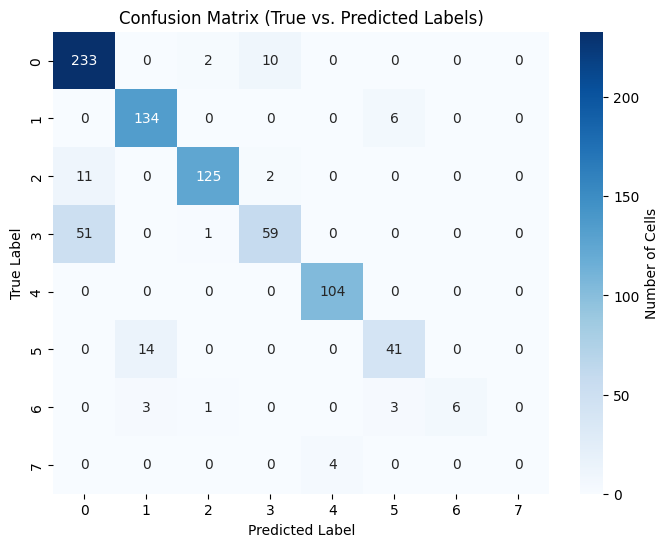


--- Per-Class ROC AUC (One-vs-Rest) ---


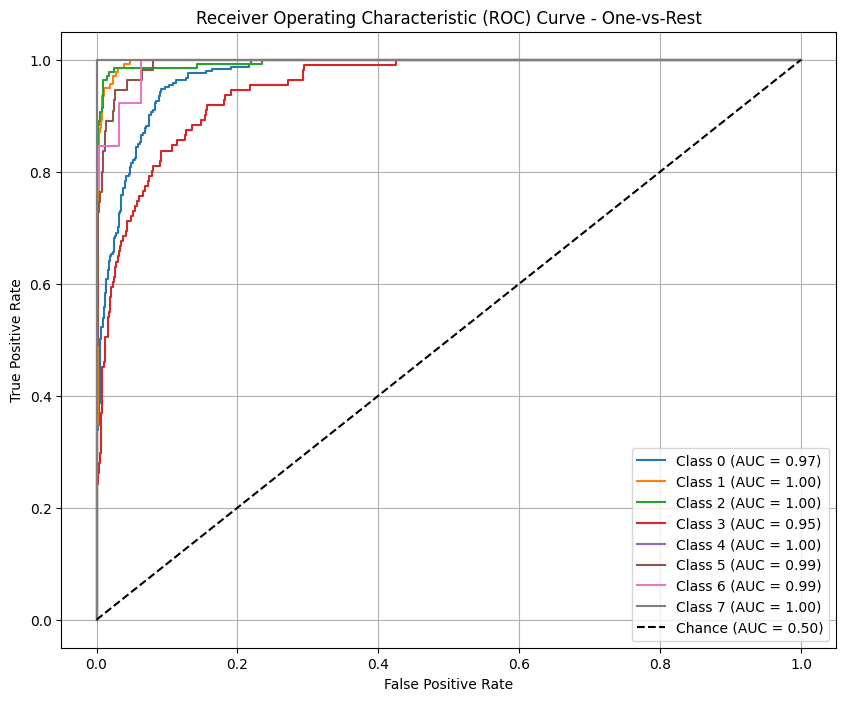


--- Distribution of Prediction Probabilities by True Class ---


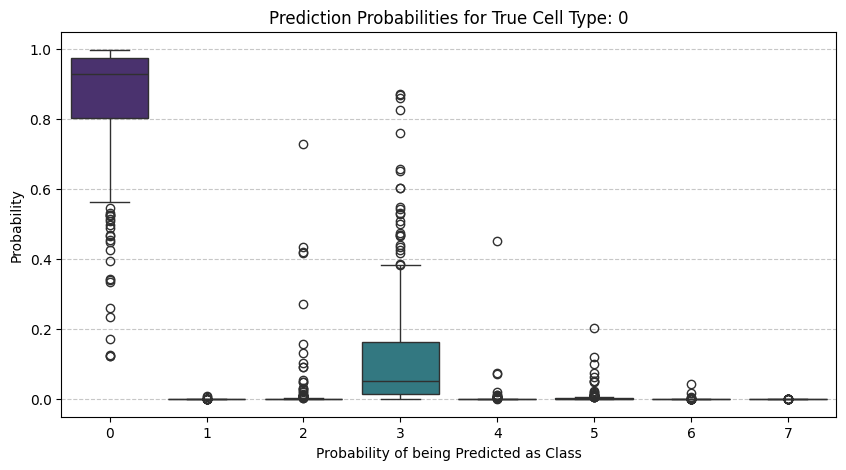

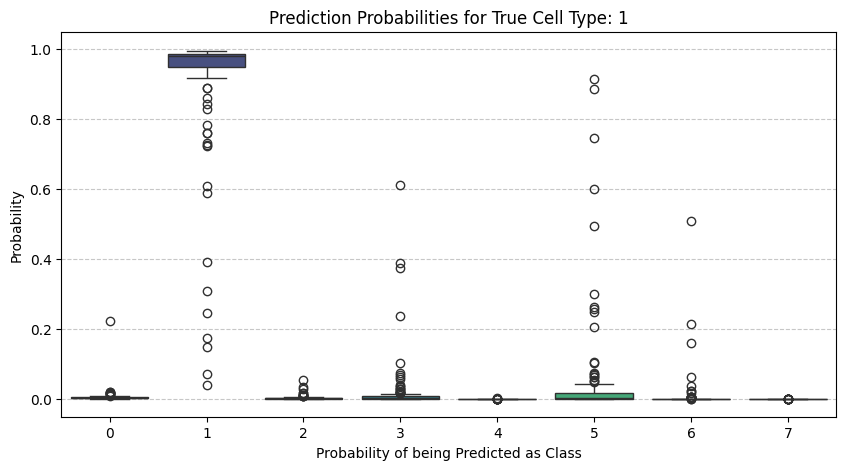

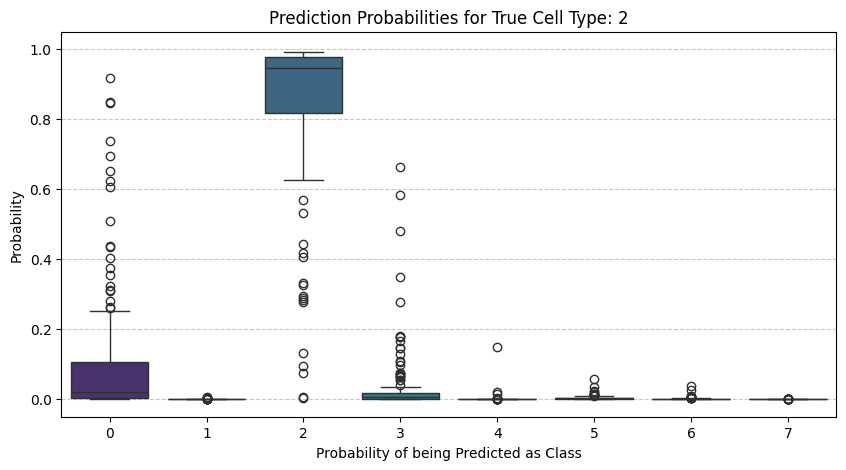

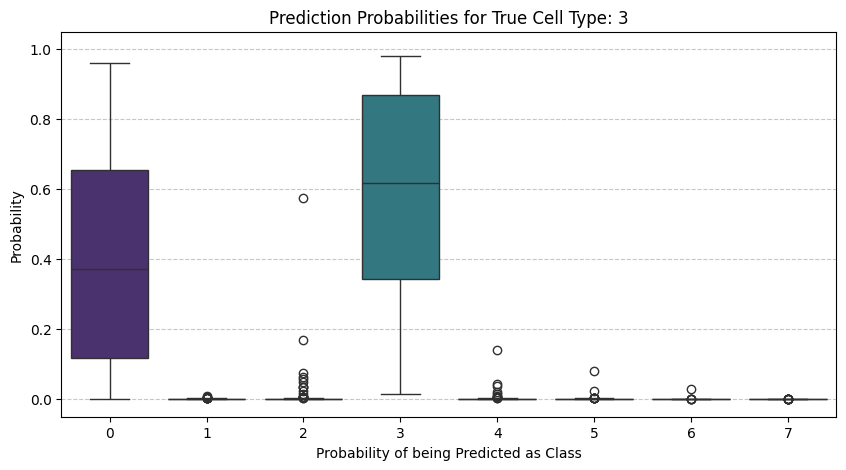

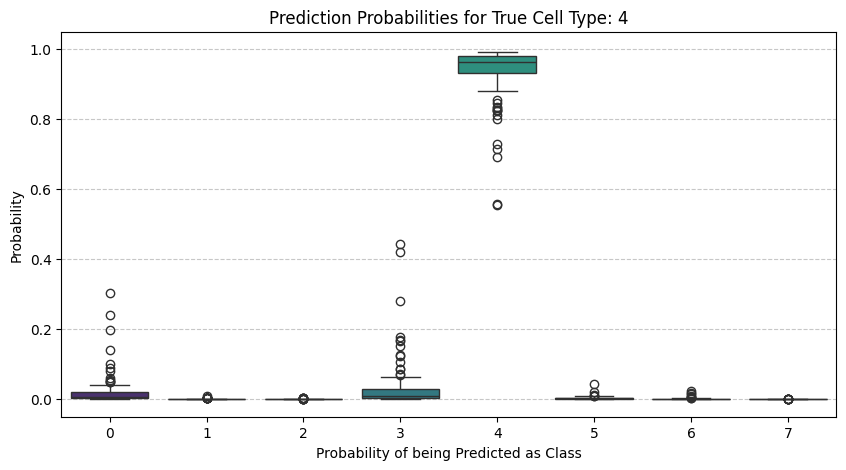

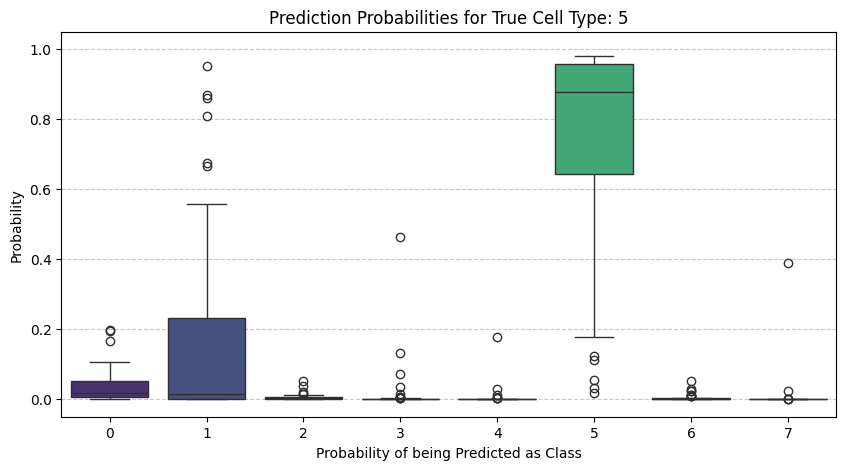

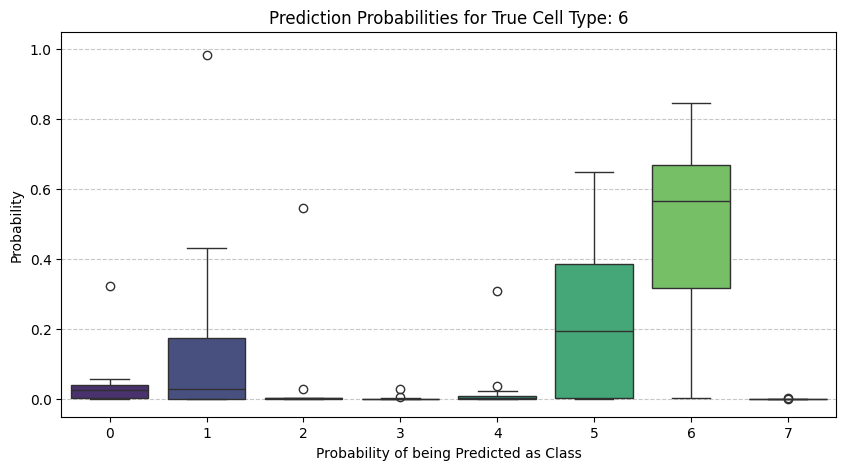

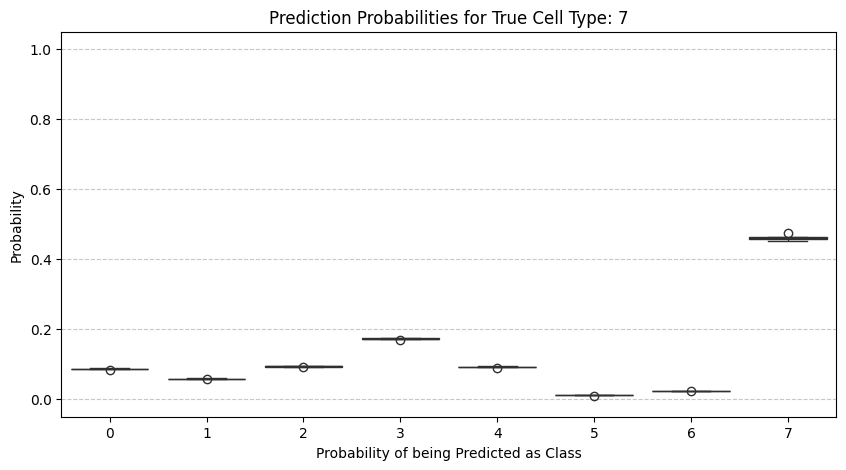


--- Plotting UMAP: True vs Predicted Labels ---


/tmp/ipykernel_10699/304681445.py:259: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.98])


<Figure size 1200x600 with 0 Axes>

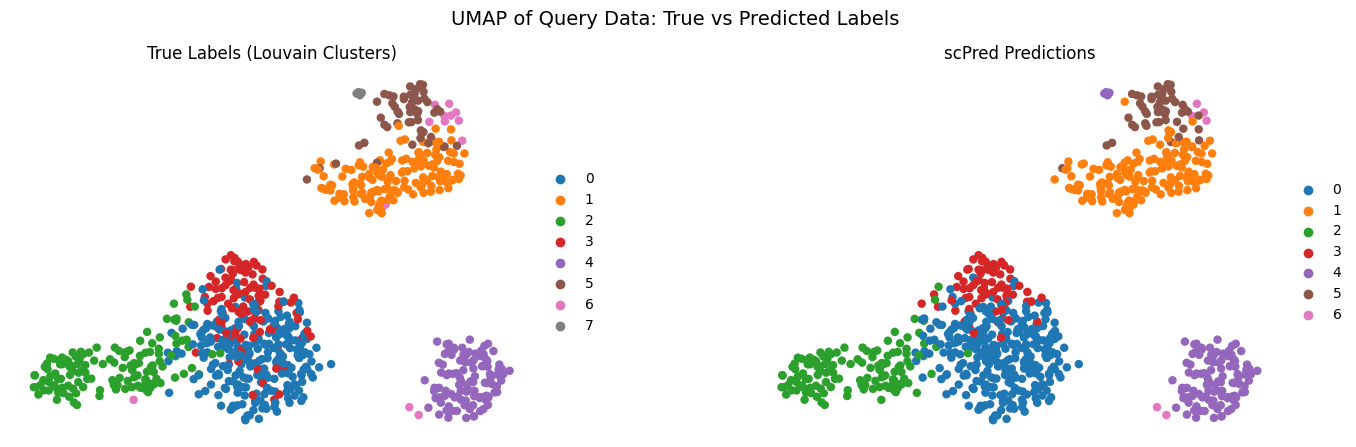


--- Plotting Misclassified Cells UMAP ---


<Figure size 800x600 with 0 Axes>

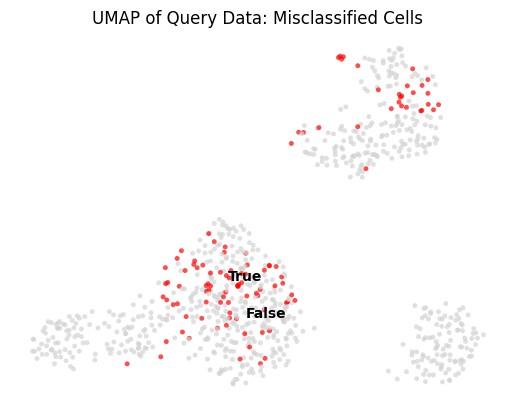


--- Plotting UMAP by Prediction Confidence ---


<Figure size 800x600 with 0 Axes>

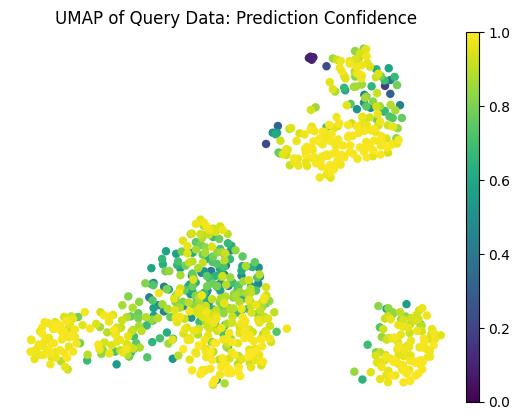


--- Analysis Complete ---


In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import os
import pickle # For saving/loading models
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure you have these installed: pip install scikit-learn scikit-misc
from sklearn.model_selection import train_test_split
from sklearn.metrics import ( # Re-import these for direct use in notebook for plots/confusion matrix
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Adjust the path to import your scpred_py_simple package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scpred_py_workhorse_v5 import ScPredModel
# Import the analysis utility functions (only for metrics now)
from scpred_py_workhorse_v5 import _analysis_utils


# --- 1. Data Loading and Initial Annotation ---
print("--- Step 1: Loading and Annotating Data ---")
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()

print(f"Initial raw AnnData object shape: {adata.shape}")
print(f"Initial raw AnnData .obs keys: {adata.obs.keys().tolist()}")
print(f"Initial raw AnnData .var keys: {adata.var.keys().tolist()}\n")


# Generate 'cell_type' labels using a temporary preprocessing pipeline
# This prepares the `adata` object with raw counts and the `cell_type` column
print("Generating temporary cell type labels via Louvain clustering...")
temp_adata_for_labels = adata.copy()
sc.pp.filter_cells(temp_adata_for_labels, min_genes=200)
sc.pp.filter_genes(temp_adata_for_labels, min_cells=3)
sc.pp.normalize_total(temp_adata_for_labels, target_sum=1e4)
sc.pp.log1p(temp_adata_for_labels)
sc.pp.highly_variable_genes(temp_adata_for_labels, min_mean=0.0125, max_mean=3, min_disp=0.5, flavor='seurat')
temp_adata_hvg_for_labels = temp_adata_for_labels[:, temp_adata_for_labels.var.highly_variable].copy()
sc.pp.scale(temp_adata_hvg_for_labels, max_value=10)
sc.tl.pca(temp_adata_hvg_for_labels, svd_solver='arpack')
sc.pp.neighbors(temp_adata_hvg_for_labels, n_neighbors=10, n_pcs=40)
sc.tl.louvain(temp_adata_hvg_for_labels, random_state=42, key_added='cell_type')

# Assign the generated cell_type labels back to the original raw adata object
adata.obs['cell_type'] = temp_adata_hvg_for_labels.obs['cell_type'].reindex(adata.obs_names)

print(f"Full dataset (raw counts + Louvain labels) shape: {adata.shape}")
print(f"Full dataset .obs keys after labeling: {adata.obs.keys().tolist()}")
print("Cell type distribution (all data):\n", adata.obs['cell_type'].value_counts())


# --- 2. Train-Test Split (Stratified) ---
# We split the raw data (with labels) into reference and query sets.
print("\n--- Step 2: Splitting Data (Stratified) ---")
indices = range(adata.n_obs)

ref_idx, query_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=42,
    stratify=adata.obs['cell_type'] # CRITICAL for balanced classes
)

# These AnnData objects contain raw counts and cell_type labels.
# The ScPredModel will handle their internal preprocessing.
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()

print(f"Reference data (raw + labels) shape: {ref_adata_raw.shape}")
print(f"Query data (raw + labels) shape: {query_adata_raw.shape}")
print("\nReference cell type distribution:\n", ref_adata_raw.obs['cell_type'].value_counts())
print("\nQuery cell type distribution:\n", query_adata_raw.obs['cell_type'].value_counts())


# --- 3. Training the scPred Model ---
# The ScPredModel will now handle all preprocessing (normalization, log1p, HVG, scaling, PCA) internally.
print("\n--- Step 3: Training scPred Model ---")
scpred_model = ScPredModel()

# Train the model on the raw reference data.
# We are also passing some configuration options for HVG selection and SVM.
scpred_model.train(
    ref_adata=ref_adata_raw, # Pass the raw reference data
    cell_type_key='cell_type',
    n_components=30,
    hvg_n_top_genes=1000, # Example: Select top 1000 HVGs
    hvg_flavor='seurat',  # Using 'seurat' flavor for HVG selection
    svm_kernel='rbf',     # Using RBF kernel for SVM (more common in scPred)
    svm_c=1.0,            # Default C parameter for SVM
    svm_random_state=42
)

print("\nModel Trained!")
print(f"Scaler: {scpred_model.scaler_}")
print(f"PCA Model: {scpred_model.pca_model_}")
print(f"Classifier: {scpred_model.classifier_}")
print(f"Reference HVGs learned: {len(scpred_model.reference_hvg_genes_)} genes")


# --- 4. Predicting with the scPred Model ---
# The model will use its saved preprocessing steps and trained classifier to predict.
print("\n--- Step 4: Predicting on Query Data ---")
query_adata_pred = scpred_model.predict(query_adata_raw) # Pass the raw query data

print("\nQuery Data with Predictions (first 5 rows):")
print(query_adata_pred.obs[['cell_type', 'scpred_prediction']].head())
print(f"\nQuery data .obs keys after prediction: {query_adata_pred.obs.keys().tolist()}")
print(f"Query data .obsm keys after prediction: {list(query_adata_pred.obsm.keys())}")


# --- 5. Evaluating Predictions (using _analysis_utils for metrics) ---
true_labels = query_adata_pred.obs['cell_type']
predicted_labels = query_adata_pred.obs['scpred_prediction']

# Extract prediction probabilities (columns starting with 'scpred_prob_')
# and ensure they are ordered according to the classifier's classes
pred_prob_cols = [col for col in query_adata_pred.obs.columns if col.startswith('scpred_prob_')]
y_pred_probs_df = None
if len(pred_prob_cols) > 0:
    y_pred_probs_df = query_adata_pred.obs[pred_prob_cols].copy()

# Use the helper function for metrics
metrics_results = _analysis_utils.evaluate_and_report_metrics(
    true_labels=true_labels,
    predicted_labels=predicted_labels,
    classifier_classes=scpred_model.classifier_.classes_, # Pass classifier classes for robust reporting
    y_pred_probs=y_pred_probs_df
)


# --- 6. Visualizing Results (plotting code directly in notebook) ---
print("\n--- Step 6: Visualizing Results ---")

# Ensure UMAP embedding is computed on the projected PCs if not already present
if 'X_scpred_pca' in query_adata_pred.obsm and 'X_umap' not in query_adata_pred.obsm:
    print("Computing neighbors and UMAP based on X_scpred_pca for visualization...")
    sc.pp.neighbors(query_adata_pred, n_neighbors=10, use_rep='X_scpred_pca')
    sc.tl.umap(query_adata_pred, random_state=42)
    print(f"Query data .obsm keys after UMAP: {list(query_adata_pred.obsm.keys())}")
elif 'X_umap' not in query_adata_pred.obsm:
    print("X_scpred_pca or X_umap not found in .obsm. UMAP plots might not be generated.")


# Plot 1: Confusion Matrix
print("\n--- Confusion Matrix ---")
# Ensure labels are string type consistently
true_labels_str = true_labels.astype(str)
predicted_labels_str = predicted_labels.astype(str)
cm_labels_str = sorted(true_labels_str.unique().tolist()) # Get all true labels for consistency
cm = confusion_matrix(true_labels_str, predicted_labels_str, labels=cm_labels_str)
cm_df = pd.DataFrame(cm, index=cm_labels_str, columns=cm_labels_str)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Cells'})
plt.title('Confusion Matrix (True vs. Predicted Labels)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# Plot 2: Per-Class ROC AUC (One-vs-Rest)
print("\n--- Per-Class ROC AUC (One-vs-Rest) ---")
# ROC AUC is only meaningful if classifier.predict_proba is available
if hasattr(scpred_model.classifier_, 'predict_proba'):
    # Prepare data for one-vs-rest ROC AUC
    classes = scpred_model.classifier_.classes_
    
    # Create binary labels for each class (one-hot encoding style)
    y_true_binary = pd.get_dummies(true_labels_str, columns=classes, drop_first=False).values
    
    # Get prediction probabilities
    y_scores = y_pred_probs_df[[f"scpred_prob_{c}" for c in classes]].values # Use the df we already prepared

    plt.figure(figsize=(10, 8))
    for i, class_label in enumerate(classes):
        if y_true_binary.shape[1] > i and len(np.unique(y_true_binary[:, i])) > 1: # Check if class has both 0 and 1
            fpr, tpr, _ = roc_curve(y_true_binary[:, i], y_scores[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})')
        else:
            print(f"Skipping ROC plot for Class {class_label}: Not enough unique true labels.")

    plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
else:
    print("Classifier does not support `predict_proba`, cannot compute ROC AUC.")


# Plot 3: Distribution of Prediction Probabilities by True Class
print("\n--- Distribution of Prediction Probabilities by True Class ---")
if hasattr(scpred_model.classifier_, 'predict_proba'):
    prob_df = query_adata_pred.obs[[f"scpred_prob_{c}" for c in scpred_model.classifier_.classes_]].copy()
    prob_df['true_cell_type'] = query_adata_pred.obs['cell_type'].astype(str)

    # Melt the DataFrame for easier plotting with seaborn
    prob_melted = prob_df.melt(
        id_vars='true_cell_type',
        value_vars=[f"scpred_prob_{c}" for c in scpred_model.classifier_.classes_],
        var_name='predicted_class_prob_of',
        value_name='probability'
    )
    prob_melted['predicted_class_prob_of'] = prob_melted['predicted_class_prob_of'].str.replace('scpred_prob_', '')

    # Plotting loop for each true cell type
    for true_type in sorted(prob_melted['true_cell_type'].unique()):
        plt.figure(figsize=(10, 5))
        subset_df = prob_melted[prob_melted['true_cell_type'] == true_type]
        sns.boxplot(
            data=subset_df,
            x='predicted_class_prob_of',
            y='probability',
            hue='predicted_class_prob_of',
            palette='viridis',
            legend=False
        )
        plt.title(f'Prediction Probabilities for True Cell Type: {true_type}')
        plt.xlabel('Probability of being Predicted as Class')
        plt.ylabel('Probability')
        plt.ylim(-0.05, 1.05) # Consistent y-axis limits
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
else:
    print("Classifier does not support `predict_proba`, cannot visualize probability distributions.")


# Plot 4: True vs Predicted Labels UMAP
if 'X_umap' in query_adata_pred.obsm:
    print("\n--- Plotting UMAP: True vs Predicted Labels ---")
    plt.figure(figsize=(12, 6)) # Use figsize here to control the overall figure size
    
    sc.pl.umap(
        query_adata_pred,
        color=['cell_type', 'scpred_prediction'],
        title=['True Labels (Louvain Clusters)', 'scPred Predictions'],
        frameon=False,
        show=False, # Set show=False to control display manually
        ncols=2,
        # Removed: ax_fontsize=12,
        wspace=0.3 # Adjust horizontal space between subplots
    )
    plt.suptitle('UMAP of Query Data: True vs Predicted Labels', y=1.02, fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()
else:
    print("Skipping UMAP: True vs Predicted Labels as 'X_umap' is not available in .obsm.")


# Plot 5: Misclassified Cells UMAP
if 'X_umap' in query_adata_pred.obsm:
    print("\n--- Plotting Misclassified Cells UMAP ---")
    # Ensure true_labels_str and predicted_labels_str are available (as they are in notebook scope)
    true_labels_str = query_adata_pred.obs['cell_type'].astype(str)
    predicted_labels_str = query_adata_pred.obs['scpred_prediction'].astype(str)

    query_adata_pred.obs['misclassified'] = (true_labels_str != predicted_labels_str).astype(str).astype('category')
    misclassified_palette = {'True': 'red', 'False': 'lightgray'}
    
    plt.figure(figsize=(8, 6))
    sc.pl.umap(
        query_adata_pred,
        color='misclassified',
        palette=misclassified_palette,
        size=50,
        alpha=0.7,
        title='UMAP of Query Data: Misclassified Cells',
        frameon=False,
        show=False,
        legend_loc='on data'
    )
    plt.show()
else:
    print("Skipping Misclassified Cells UMAP as 'X_umap' is not available in .obsm.")


# Plot 6: UMAP colored by Prediction Confidence
if 'X_umap' in query_adata_pred.obsm and hasattr(scpred_model.classifier_, 'predict_proba'):
    print("\n--- Plotting UMAP by Prediction Confidence ---")
    # Get the probability for the *predicted* class for each cell
    def get_predicted_prob(row, classes):
        pred_class = row['scpred_prediction']
        prob_col_name = f'scpred_prob_{pred_class}'
        if prob_col_name in row.index:
            return row[prob_col_name]
        return np.nan

    prob_cols = [f"scpred_prob_{c}" for c in scpred_model.classifier_.classes_]
    
    if not all(col in query_adata_pred.obs.columns for col in prob_cols):
        print("Skipping UMAP by prediction confidence: Required probability columns not found in .obs.")
    else:
        temp_obs_for_apply = query_adata_pred.obs[['scpred_prediction'] + prob_cols]
        query_adata_pred.obs['predicted_prob_score'] = temp_obs_for_apply.apply(
            lambda row: get_predicted_prob(row, scpred_model.classifier_.classes_), axis=1
        )

        plt.figure(figsize=(8, 6))
        sc.pl.umap(
            query_adata_pred,
            color='predicted_prob_score',
            cmap='viridis',
            title='UMAP of Query Data: Prediction Confidence',
            frameon=False,
            vmin=0.0, vmax=1.0,
            show=False
        )
        plt.show()
else:
    print("Skipping UMAP by prediction confidence: 'X_umap' not available or classifier does not support `predict_proba`.")

print("\n--- Analysis Complete ---")
